# Machine Learning Model

In this section, I build a predictive machine learning model using the cleaned parking tickets dataset. The goal is to predict the ticket amount based on location, time, vehicle, and offense-related features.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("clean_parking_tickets.csv")

df.head()

,ticket_number,district,street,between_street_1,between_street_2,gps,ticket_start_time,ticket_end_time,state,vehicle_make,...,ticket_amount,offense_description,ticket_year,ticket_month,ticket_day,ticket_day_name,ticket_hour,is_weekend,latitude,longitude
0,HA37028672,NW,QUIMBY ST,21ST AVE,22ND AVE,45.50387221;-122.57663717,2023-01-02 08:25:00,2023-01-02 08:27:00,OR,ACURA,...,95,LOADING ZONE,2023,1,2,Monday,8,False,45.503872,-122.576637
1,HA37081166,NW,DAVIS ST,14TH AVE,15TH AVE,45.52453771;-122.68629165,2023-01-02 08:59:00,2023-01-02 09:00:00,WA,DODGE,...,65,NO METER RECEIPT,2023,1,2,Monday,8,False,45.524538,-122.686292
2,HA37081168,NW,EVERETT ST,14TH AVE,15TH AVE,45.52447901;-122.68613714,2023-01-02 09:05:00,2023-01-02 09:06:00,OR,TOYOTA,...,65,NO METER RECEIPT,2023,1,2,Monday,9,False,45.524479,-122.686137
3,HA37081169,NW,FLANDERS ST,14TH AVE,15TH AVE,45.5249296;-122.6857147,2023-01-02 09:09:00,2023-01-02 09:10:00,CA,FORD,...,145,FAILURE TO DISPLAY CURRENT REGISTRATION (91 OR...,2023,1,2,Monday,9,False,45.524930,-122.685715
4,HA37072803,NE,ALBERTA ST,Unknown,Unknown,45.52841746;-122.64454197,2023-01-02 09:14:00,2023-01-02 09:15:00,OR,CADILLAC,...,105,BUS ZONE,2023,1,2,Monday,9,False,45.528417,-122.644542


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249472 entries, 0 to 249471
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ticket_number        249472 non-null  object 
 1   district             249472 non-null  object 
 2   street               249472 non-null  object 
 3   between_street_1     249472 non-null  object 
 4   between_street_2     249472 non-null  object 
 5   gps                  249472 non-null  object 
 6   ticket_start_time    249472 non-null  object 
 7   ticket_end_time      249472 non-null  object 
 8   state                249472 non-null  object 
 9   vehicle_make         249472 non-null  object 
 10  offense_code         249472 non-null  int64  
 11  ticket_amount        249472 non-null  int64  
 12  offense_description  249472 non-null  object 
 13  ticket_year          249472 non-null  int64  
 14  ticket_month         249472 non-null  int64  
 15  ticket_day       

In [9]:
df.isna().sum()

ticket_number          0
district               0
street                 0
between_street_1       0
between_street_2       0
gps                    0
ticket_start_time      0
ticket_end_time        0
state                  0
vehicle_make           0
offense_code           0
ticket_amount          0
offense_description    0
ticket_year            0
ticket_month           0
ticket_day             0
ticket_day_name        0
ticket_hour            0
is_weekend             0
latitude               0
longitude              0
dtype: int64

In [11]:
target= "ticket_amount"

In [13]:
features = [
    "district",
    "street",
    "between_street_1",
    "between_street_2",
    "state",
    "vehicle_make",
    "offense_code",
    "offense_description",
    "ticket_year",
    "ticket_month",
    "ticket_day",
    "ticket_day_name",
    "ticket_hour",
    "is_weekend",
    "latitude",
    "longitude"
]


In [19]:
X= df[features]

In [20]:
y=df[target]

In [21]:
X.isna().sum()

district               0
street                 0
between_street_1       0
between_street_2       0
state                  0
vehicle_make           0
offense_code           0
offense_description    0
ticket_year            0
ticket_month           0
ticket_day             0
ticket_day_name        0
ticket_hour            0
is_weekend             0
latitude               0
longitude              0
dtype: int64

In [23]:
categorical_features = [
    "district",
    "street",
    "between_street_1",
    "between_street_2",
    "state",
    "vehicle_make",
    "offense_code",
    "offense_description",
    "ticket_day_name",
    "is_weekend"
]

numeric_features = [
    "ticket_year",
    "ticket_month",
    "ticket_day",
    "ticket_hour",
    "latitude",
    "longitude"
]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 42
)

X_train.shape, X_test.shape

((199577, 16), (49895, 16))

In [30]:
preprocessor = ColumnTransformer(
    transformers =[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [33]:
linear_model = Pipeline(
    steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
    ]
)
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['district', 'street',
                                                   'between_street_1',
                                                   'between_street_2', 'state',
                                                   'vehicle_make',
                                                   'offense_code',
                                                   'offense_description',
                                                   'ticket_day_name',
                                                   'is_weekend']),
                                                 ('num', StandardScaler(),
                                                  ['ticket_year',
                                                   'ticket_month', 'ticket_day',
                                                   'ticket_hour', 'latitude',
                                                   'longitude'])])),
                ('model', LinearRegression())])

In [35]:
y_pred_linear = linear_model.predict(X_test)

In [36]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Performance
MAE: 0.0024300146398370743
RMSE: 0.14729600153442743
R²: 0.9999824032595841


In [37]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=15
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['district', 'street',
                                                   'between_street_1',
                                                   'between_street_2', 'state',
                                                   'vehicle_make',
                                                   'offense_code',
                                                   'offense_description',
                                                   'ticket_day_name',
                                                   'is_weekend']),
                                                 ('num', StandardScaler(),
                                                  ['ticket_year',
                                                   'ticket_month', 'ticket_day',
                                                   'ticket_hour', 'latitude',
                                                   'longitude'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, n_jobs=-1,
                                       random_state=42))])

In [38]:
y_pred_rf = rf_model.predict(X_test)

In [40]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Performance
MAE: 1.2818707770418274
RMSE: 5.342250993295482
R²: 0.976852777357734


In [41]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2 Score": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.002430,0.147296,0.999982
1,Random Forest,1.281871,5.342251,0.976853


The models were evaluated using MAE, RMSE, and R² score. MAE shows the average dollar error in predictions, RMSE penalizes larger errors more heavily, and R² shows how much variation in ticket amount is explained by the model.

In [42]:
comparison_df = pd.DataFrame({
    "Actual Ticket Amount": y_test.values,
    "Predicted Ticket Amount": y_pred_rf
})

comparison_df.head(20)

,Actual Ticket Amount,Predicted Ticket Amount
0,65,65.000000
1,95,84.375526
2,65,65.000000
3,85,84.375526
4,44,44.000000
5,65,65.000000
6,65,84.375526
7,85,84.375526
8,55,84.375526
9,95,95.000000


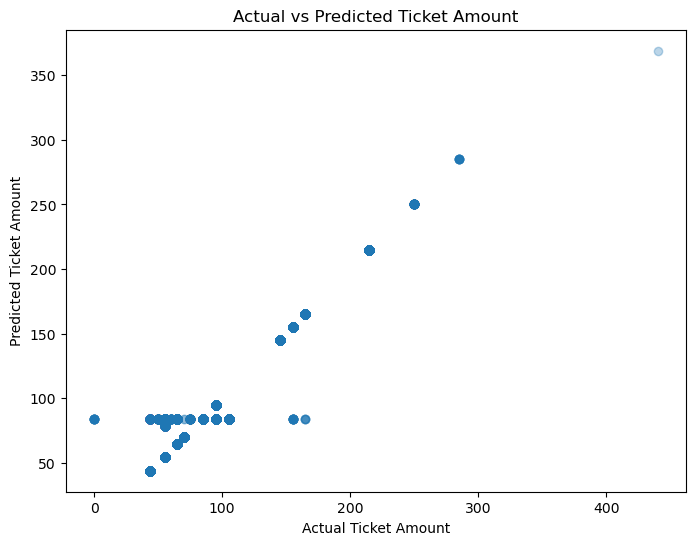

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Ticket Amount")
plt.ylabel("Predicted Ticket Amount")
plt.title("Actual vs Predicted Ticket Amount")
plt.show()

The model performed well because ticket amounts are strongly related to the offense code and offense description. These features directly describe the type of violation, which is one of the main factors determining the ticket amount.

To avoid data leakage, the `offense_amount` column was removed because it was nearly identical to the target variable `ticket_amount`.

# Conclusion

This project cleaned and prepared a parking ticket dataset for analysis and machine learning. The ticket data was merged with the offense code dataset to add violation descriptions. Missing values were handled, columns were renamed for consistency, unnecessary columns were removed, and data types were converted appropriately.

For machine learning, the target variable was `ticket_amount`. A baseline Linear Regression model and a Random Forest Regressor were trained and tested using an 80/20 train-test split. Model performance was evaluated using MAE, RMSE, and R² score. The Random Forest model was expected to perform better because it can capture non-linear relationships between offense type, location, time, and ticket amount.

The results show that ticket amount can be predicted using features such as offense code, offense description, district, street, vehicle state, ticket time, and location. The `offense_amount` column was removed before modeling to avoid data leakage because it was nearly identical to the target variable.